In [ ]:
import tensorflow as tf
from transformers import TFAutoModelForCausalLM, AutoTokenizer



In [ ]:
model = TFAutoModelForCausalLM.from_pretrained("model1")

In [ ]:
test_sentence = "I am your doctor, my name is"

In [41]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
tokenized = tokenizer(test_sentence, return_tensors="np")

outputs = model.generate(**tokenized, max_length=24)

tokenizer.decode(outputs[0])

'I am your doctor, my name is Smith.  You have been\nadmitted to the hospital because you were found'

In [ ]:
#conda install git

In [ ]:
#pip install -U git+https://github.com/tensorflow/privacy

In [ ]:
pip install immutabledict

In [ ]:
pip install statsmodels

In [ ]:
pip install --no-cache-dir git+https://github.com/tensorflow/privacy


In [ ]:
import tensorflow_privacy.privacy.privacy_tests.membership_inference_attack.membership_inference_attack as mia
from tensorflow_privacy.privacy.privacy_tests.membership_inference_attack.data_structures import AttackInputData
from tensorflow_privacy.privacy.privacy_tests.membership_inference_attack.data_structures import SlicingSpec
from tensorflow_privacy.privacy.privacy_tests.membership_inference_attack.data_structures import AttackType

In [42]:
train_texts = ["Hello, how are you?", "The weather is nice today.", "Let's go to the park."]
train_encodings = tokenizer(train_texts, return_tensors="tf", padding=True, truncation=True)

# Convert to TensorFlow dataset
train_dataset = tf.data.Dataset.from_tensor_slices(train_encodings).batch(8)

In [43]:
import numpy as np

loss_train = []

for batch in train_dataset:
    inputs = {k: v for k, v in batch.items()}
    
    # Set labels to be the input IDs (GPT-2 uses input_ids as labels for CLM)
    inputs["labels"] = inputs["input_ids"]

    # Forward pass
    outputs = model(**inputs, training=False)  # training=False to avoid dropout effects
    
    # Extract per-example loss
    per_example_loss = outputs.loss.numpy()
    
    # Store the losses
    loss_train.append(per_example_loss)

# Convert to a numpy array
loss_train = np.concatenate(loss_train, axis=0)

# Print shape
print(f"Loss Train Shape: {loss_train.shape}")  # Should be (n_train,)


Loss Train Shape: (1,)


In [44]:
average_train_loss = np.mean(loss_train)
print(f"Average Training Loss: {average_train_loss:.4f}")

Average Training Loss: 5.4318


In [46]:
attacks_result = mia.run_attacks(
    AttackInputData(loss_train=loss_train, loss_test=loss_train)
)

In [48]:
print(attacks_result.summary())

Best-performing attacks over all slices
  THRESHOLD_ATTACK (with 1 training and 1 test examples) achieved an AUC of 0.50 on slice Entire dataset
  THRESHOLD_ATTACK (with 1 training and 1 test examples) achieved an advantage of 0.00 on slice Entire dataset
  THRESHOLD_ATTACK (with 1 training and 1 test examples) achieved a positive predictive value of 0.50 on slice Entire dataset
  THRESHOLD_ATTACK (with 1 training and 1 test examples) achieved top-5 epsilon lower bounds of -2.6905, -2.6905 on slice Entire dataset


In [50]:
pip install matplotlib

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 35.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 33.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


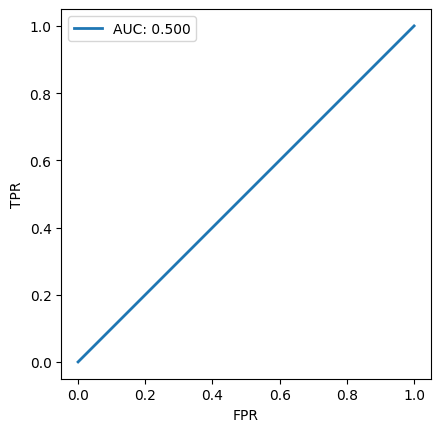

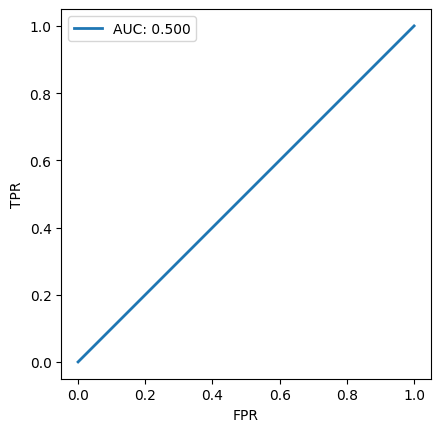

In [51]:
import tensorflow_privacy.privacy.membership_inference_attack.plotting as plotting
plotting.plot_roc_curve(attacks_result.get_result_with_max_auc().roc_curve)